In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def build_plot(activation, name):
    x = torch.linspace(-5, 5, 1000)
    y = activation(x) if callable(activation) else activation(x)
    plt.plot(x.numpy(), y.detach().numpy(), label=name)
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')  # ось X
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')  # ось Y
    plt.title(name)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

## ReLU (Rectified Linear Unit)

✅ Использовать:
* В глубоких нейронных сетях (особенно CNN, MLP).
* При обучении без риска "мертвых нейронов" (правильная инициализация весов).
* В задачах классификации и регрессии.

❌ Не использовать:
* Если слишком много нейронов становятся "мертвыми" (входные значения всегда отрицательны).
* В очень глубоких сетях, где может возникнуть vanishing gradient.
* В RNN (рекуррентных нейронных сетях) – может вызвать exploding gradients.

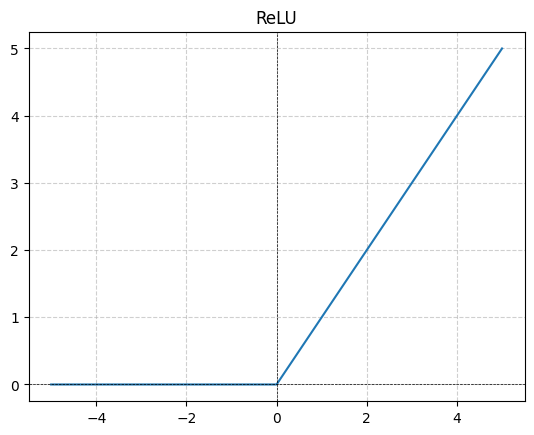

In [2]:
build_plot(nn.ReLU(), "ReLU")

## LeakyReLU (Leaky Rectified Linear Unit)

✅ Использовать:
* Когда есть проблема "мертвых нейронов" (нулевой градиент в ReLU).
* Если в сети много отрицательных значений, а их обнуление не желательно.
* В глубоких архитектурах, где ReLU показывает плохие результаты.

❌ Не использовать:
* Если стандартный ReLU работает нормально – он проще и более интерпретируем.
* В задачах, где хочется строгого "отсеивания" слабых сигналов.

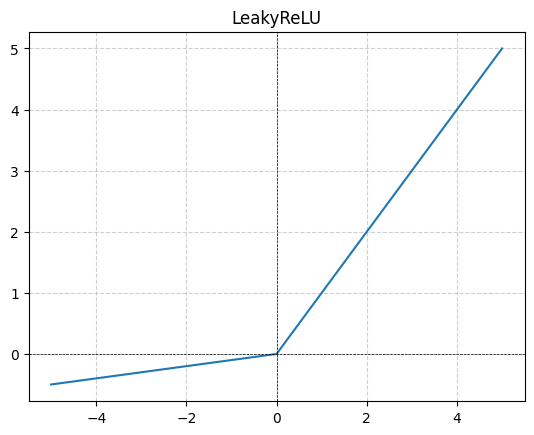

In [5]:
build_plot(nn.LeakyReLU(0.1), "LeakyReLU")

## PReLU (Parametric ReLU)

✅ Использовать:
* Когда сеть должна сама обучать коэффициент утечки  𝛼 (параметр LeakyReLU).
* В задачах с разными типами данных, где фиксированное  𝛼 (как в LeakyReLU) может быть не оптимальным.
* В глубоких сетях с различными распределениями входных данных.

❌ Не использовать:
* Когда простая ReLU или LeakyReLU уже дают хороший результат.
* Если модель маленькая, а дополнительный параметр не критичен.

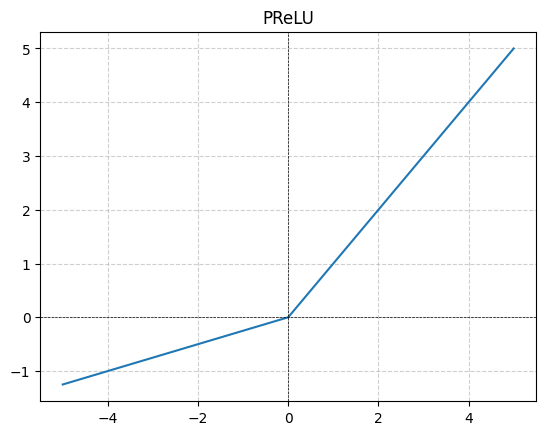

In [6]:
build_plot(nn.PReLU(), "PReLU")

## ELU (Exponential Linear Unit)

✅ Использовать:
* Если нужен плавный переход через ноль (ReLU и LeakyReLU резкие).
* В задачах с градиентными затуханиями – ELU помогает сохранить мощный градиент даже в отрицательных значениях.
* В глубоких нейронных сетях.

❌ Не использовать:
* Если нужна простая и быстрая функция (ELU вычислительно дороже, чем ReLU).
* В ресурсозатратных системах (например, в мобильных нейросетях).

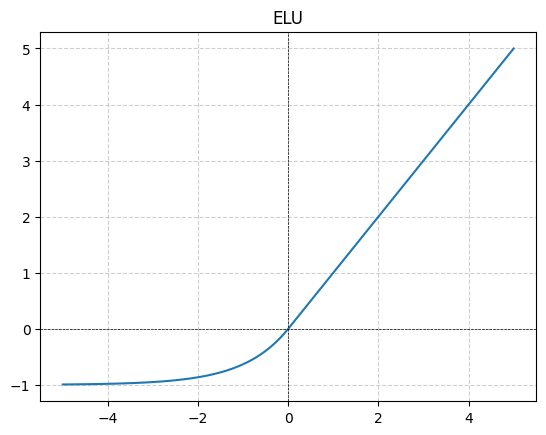

In [7]:
build_plot(nn.ELU(), "ELU")

## SELU (Scaled Exponential Linear Unit)

✅ Использовать:
* В глубоких нейронных сетях, где нужна самонормализация (автоматическая стабилизация).
* В глубоких автоэнкодерах, поскольку помогает поддерживать активность сети.
* Если batch normalization не подходит.

❌ Не использовать:
* Если сеть использует batch normalization (SELU и BN плохо совместимы).
* В простых моделях, где нормализация не критична.

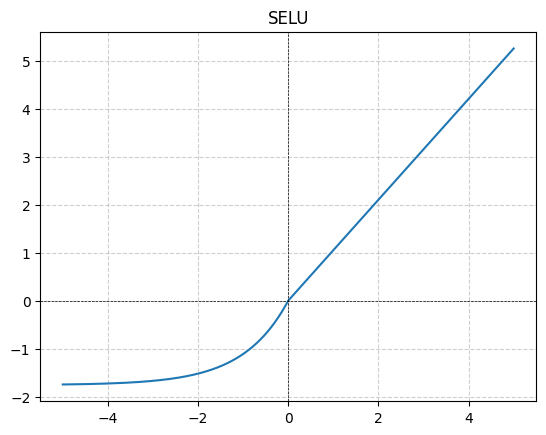

In [8]:
build_plot(nn.SELU(), "SELU")

## GELU (Gaussian Error Linear Unit)

✅ Использовать:
* В Transformer-моделях (GPT, BERT и т. д.) – улучшает плавность активации.
* В глубоких NLP-сетях – там, где Tanh и ReLU не дают хорошего качества.
* В сглаженных моделях, где резкие изменения ReLU мешают.

❌ Не использовать:
* В простых нейросетях – слишком сложен по сравнению с ReLU.
* В мобильных моделях – дорого считать.

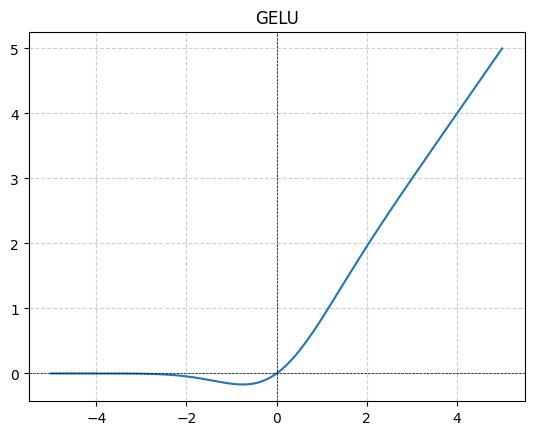

In [9]:
build_plot(nn.GELU(), "GELU")

## Softplus

✅ Использовать:
* Если нужно сглаженное ReLU
* В задачах, где важны градиенты без резких скачков.
* В некоторых байесовских моделях.

❌ Не использовать:
* Если важна скорость вычислений (ReLU проще и быстрее).
* В глубоких сетях, где большие положительные значения могут увеличивать дисбаланс.

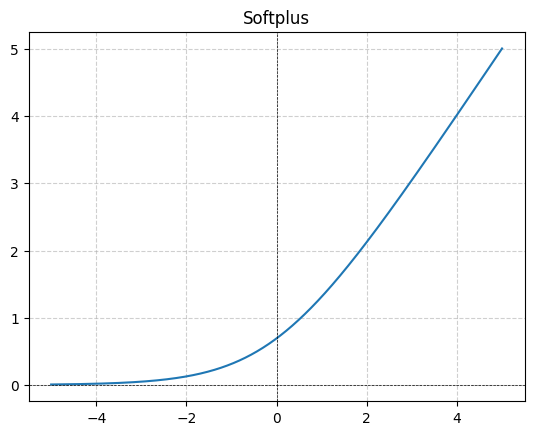

In [10]:
build_plot(nn.Softplus(), "Softplus")

## Sigmoid

✅ Использовать:
* В выходном слое бинарной классификации.
* В нормализации значений (например, attention-механизмы).
* В нейросетях, работающих с вероятностями.

❌ Не использовать:
* В глубоких слоях – вызывает vanishing gradient.
* Если значения должны сохранять знак (Sigmoid все загоняет в диапазон [0,1]).

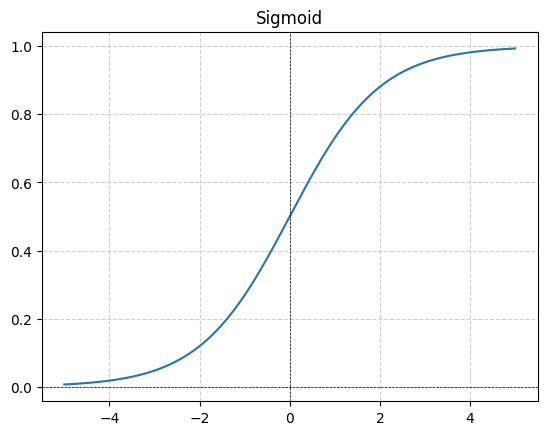

In [11]:
build_plot(nn.Sigmoid(), "Sigmoid")

## Hardsigmoid

✅ Использовать:
* Если нужна приближенная и быстрая версия Sigmoid.
* В мобильных моделях, где важна скорость.

❌ Не использовать:
* Если требуется точность, а не скорость.

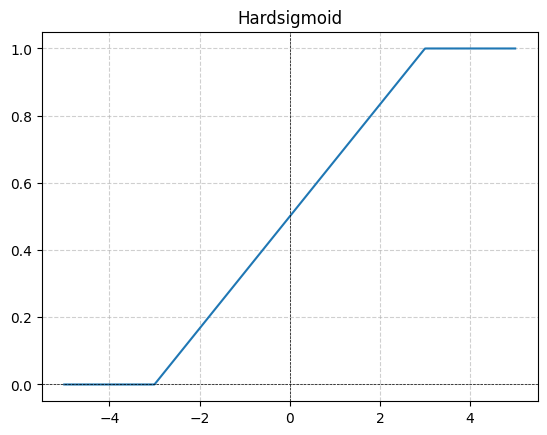

In [12]:
build_plot(nn.Hardsigmoid(), "Hardsigmoid")

## Tanh (Гиперболический тангенс)

✅ Использовать:
* В RNN и LSTM – он центрирован в нуле, лучше Sigmoid.
* В первых слоях сети, если входные данные сильно разнятся.

❌ Не использовать:
* В глубоких слоях – проблема vanishing gradient.
* Если лучше работает ReLU.

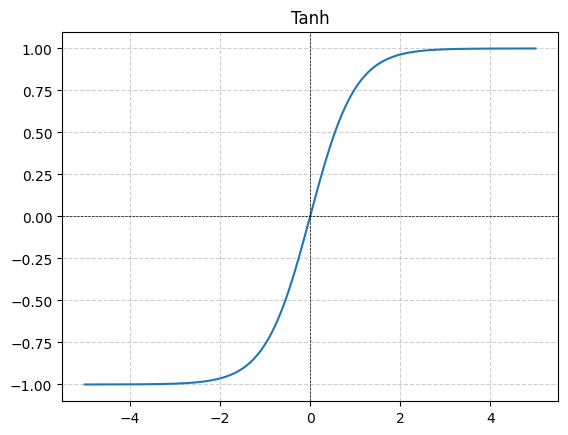

In [13]:
build_plot(nn.Tanh(), "Tanh")

## Hardtanh

✅ Использовать:
* Если нужен быстрый и обрезанный вариант tanh.
* В мобильных моделях.

❌ Не использовать:
* Если нужна гладкая активация – tanh лучше.

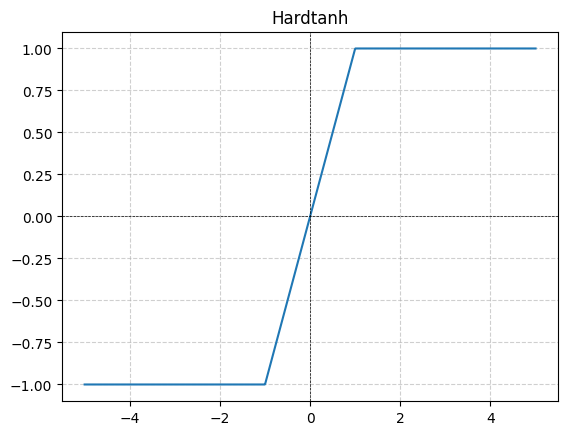

In [14]:
build_plot(nn.Hardtanh(), "Hardtanh")

## SiLU (Swish)

✅ Использовать:
* В современных NLP и компьютерном зрении (EfficientNet, Transformers).
* Когда нужно сглаженное и адаптивное поведение.

❌ Не использовать:
* В простых моделях – сложно и дорого.
* Если нужна простая интерпретация.

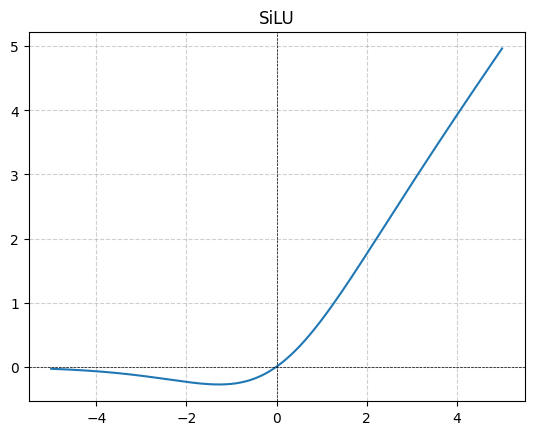

In [15]:
build_plot(nn.SiLU(), "SiLU")

## Softmax

✅ Использовать:
* В выходном слое многоклассовой классификации.
* В attention-механизмах.

❌ Не использовать:
* В промежуточных слоях – плохо для backpropagation.

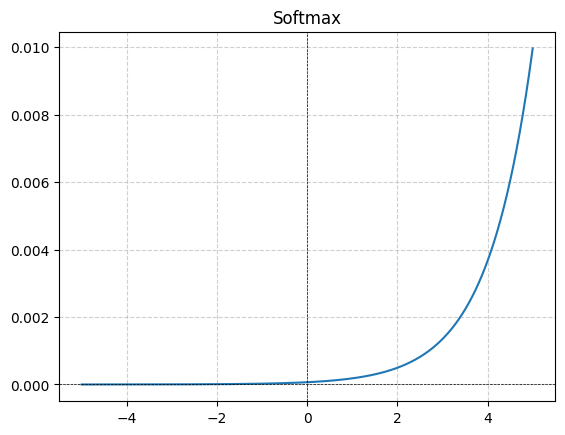

In [16]:
softmax = lambda x: torch.softmax(x, dim=0)
build_plot(softmax, "Softmax")

## LogSoftmax

✅ Использовать:
* Вместо Softmax, если модель работает с кросс-энтропией (nn.CrossEntropyLoss).
* Когда нужна числовая стабильность.

❌ Не использовать:
* В моделях, где Softmax уже дает нужный результат.


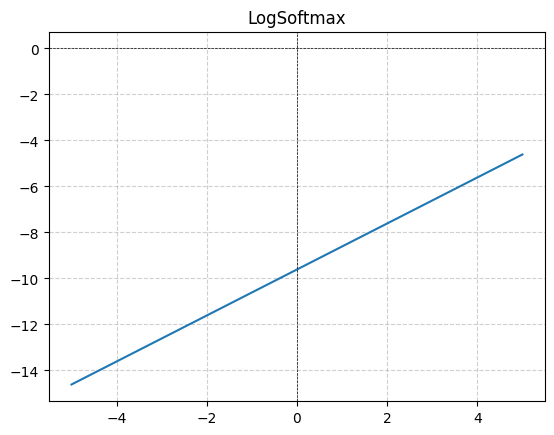

In [17]:
logSoftmax = lambda x: torch.log_softmax(x, dim=0)
build_plot(logSoftmax, "LogSoftmax")

# Вывод
* ReLU и его вариации (LeakyReLU, PReLU, ELU, GELU, SELU) → лучшие для скрытых слоев.
* Softmax / LogSoftmax → для многоклассовой классификации.
* Sigmoid / Hardsigmoid → для бинарной классификации.
* Tanh → часто в RNN.
* Swish / GELU → для новых архитектур, особенно в NLP.


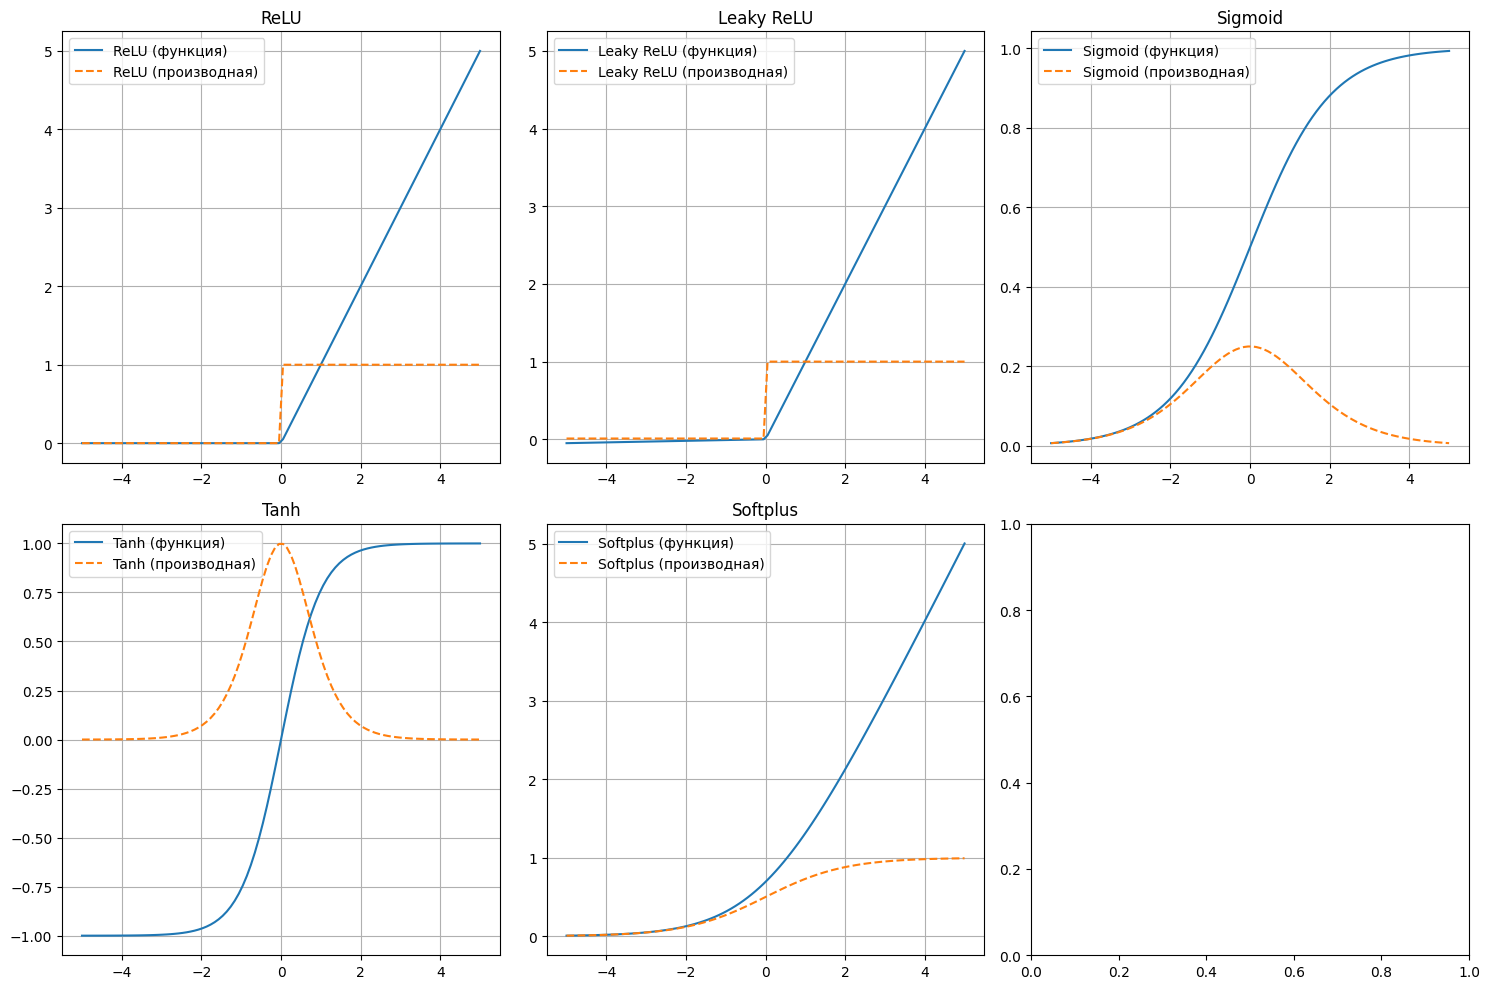

In [7]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Определение функций активации и их производных
def activation_functions(x):
    return {
        'ReLU': F.relu(x),
        'Leaky ReLU': F.leaky_relu(x, negative_slope=0.01),
        'Sigmoid': torch.sigmoid(x),
        'Tanh': torch.tanh(x),
        'Softplus': F.softplus(x)
    }

def activation_derivatives(x):
    x.requires_grad_(True)
    outputs = activation_functions(x)
    derivatives = {}
    for name, output in outputs.items():
        grad, = torch.autograd.grad(output.sum(), x, create_graph=True)
        derivatives[name] = grad.detach()
    return derivatives

# Создание входных данных
x = torch.linspace(-5, 5, 100, requires_grad=True)

# Вычисление значений и производных
values = activation_functions(x)
derivatives = activation_derivatives(x)

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, value) in enumerate(values.items()):
    axes[i].plot(x.detach().numpy(), value.detach().numpy(), label=f'{name} (функция)')
    axes[i].plot(x.detach().numpy(), derivatives[name].numpy(), label=f'{name} (производная)', linestyle='dashed')
    axes[i].set_title(name)
    axes[i].legend()
    axes[i].grid()

plt.tight_layout()
plt.show()
